## Project Objective

Evaluate the minimum clinical data required to reliably predict Alzheimer's Disease (AD).

Compare performance across statistically selected feature sets versus real-world clinical constraints.

## Dataset Overview

Size: 2,149 patient records, ages 60-90.

Features: 31 clinical features across 6 domains (Demographics, Lifestyle, Medical History, Clinical Measurements, Cognitive and Functional Assessments, Behavioral Symptoms).
+1

Target: Binary Diagnosis (0 = No AD, 1 = AD).

Distribution: Mild imbalance of 64.6% non-AD to 35.4% AD.

Quality: Zero missing values.

## Step-by-Step Workflow

Preprocessing: Remove leakage columns like PatientID , scale continuous variables, and encode categoricals.
+1

EDA: Analyze target distribution, feature shapes, and correlations.
+2

Feature Selection: Filter features using Pearson correlation, Chi-Square, Mutual Information, and Logistic Regression coefficients.

Feature Set Definition: Group features into Statistical sets like Top 10 SHAP and Clinical sets like Community Minimum.
+3

Modeling: Train Logistic Regression, Random Forest, and XGBoost using Stratified 10-Fold CV.
+2

Evaluation: Compare models using ROC-AUC, Recall, F1, and Precision.

## Methodological Justifications

SMOTE: Balances the class ratio to maximize minority class recall. Applied inside the CV pipeline to prevent data leakage.
+2

Tree-Based Models (RF & XGBoost): Required to capture complex, non-linear relationships identified during EDA.
+1

Logistic Regression: Used as a highly interpretable, linear baseline to validate feature importance.

Stratified 10-Fold CV: Ensures every fold maintains the realistic class ratio for stable evaluation.

Metrics (Recall & ROC-AUC): Prioritized because minimizing missed AD cases (false negatives) is critical in a screening context.

## Action Items for Next Steps

Code Updates

Add the missing statistical sets to the FEATURE_SETS dictionary to align the code with the report's methodology: "Chi-Square Significant set", "MI Positive set", and "Near-Zero Signal set".
+3

Fix the pandas FutureWarning regarding select_dtypes by explicitly passing "str" to the include or exclude parameters.

In [1]:
%pip install imbalanced-learn
%pip install xgboost imbalanced-learn shap statsmodels

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


In [1]:
# Import Required Libraries
# ================================

# Basic libraries
import numpy as np
import pandas as pd

# Visualization libraries
import matplotlib.pyplot as plt
import seaborn as sns

# Sklearn - Preprocessing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Sklearn - Models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

# Sklearn - Evaluation Metrics
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    roc_auc_score,
    roc_curve
)

In [3]:
#Load the dataset
data = pd.read_csv('Data/alzheimers_disease_data.csv')
print(data.head())
print(data.info())
print(data.describe())

# 2) Missing values (overall + per column)
missing_per_col = data.isna().sum().sort_values(ascending=False)
print("\nMissing values per column (top 15):")
print(missing_per_col.head(15))

# 3) Basic types
print("\nDtypes:\n", data.dtypes)

# 4) Quick numeric summary
display(data.describe(include="number").T)

# 5) Quick categorical summary (top categories)
cat_cols_guess = data.select_dtypes(include=["object", "category"]).columns
for c in cat_cols_guess[:10]:  # show first 10 only
    print(f"\nColumn: {c}")
    print(data[c].value_counts(dropna=False).head(10))


   PatientID  Age  Gender  Ethnicity  EducationLevel        BMI  Smoking  \
0       4751   73       0          0               2  22.927749        0   
1       4752   89       0          0               0  26.827681        0   
2       4753   73       0          3               1  17.795882        0   
3       4754   74       1          0               1  33.800817        1   
4       4755   89       0          0               0  20.716974        0   

   AlcoholConsumption  PhysicalActivity  DietQuality  ...  MemoryComplaints  \
0           13.297218          6.327112     1.347214  ...                 0   
1            4.542524          7.619885     0.518767  ...                 0   
2           19.555085          7.844988     1.826335  ...                 0   
3           12.209266          8.428001     7.435604  ...                 0   
4           18.454356          6.310461     0.795498  ...                 0   

   BehavioralProblems       ADL  Confusion  Disorientation  \
0     

,count,mean,std,min,25%,50%,75%,max
PatientID,2149.0,5825.000000,620.507185,4751.000000,5288.000000,5825.000000,6362.000000,6899.000000
Age,2149.0,74.908795,8.990221,60.000000,67.000000,75.000000,83.000000,90.000000
Gender,2149.0,0.506282,0.500077,0.000000,0.000000,1.000000,1.000000,1.000000
Ethnicity,2149.0,0.697534,0.996128,0.000000,0.000000,0.000000,1.000000,3.000000
EducationLevel,2149.0,1.286645,0.904527,0.000000,1.000000,1.000000,2.000000,3.000000
BMI,2149.0,27.655697,7.217438,15.008851,21.611408,27.823924,33.869778,39.992767
Smoking,2149.0,0.288506,0.453173,0.000000,0.000000,0.000000,1.000000,1.000000
AlcoholConsumption,2149.0,10.039442,5.757910,0.002003,5.139810,9.934412,15.157931,19.989293
PhysicalActivity,2149.0,4.920202,2.857191,0.003616,2.570626,4.766424,7.427899,9.987429
DietQuality,2149.0,4.993138,2.909055,0.009385,2.458455,5.076087,7.558625,9.998346



Column: DoctorInCharge
DoctorInCharge
XXXConfid    2149
Name: count, dtype: int64


/var/folders/_r/1mtvh9nn1ns69vtxm47ygl1c0000gn/T/ipykernel_1198/2441348960.py:19: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols_guess = data.select_dtypes(include=["object", "category"]).columns


Diagnosis
0    1389
1     760
Name: count, dtype: int64

Percentage Distribution:
Diagnosis
0    64.634714
1    35.365286
Name: proportion, dtype: float64


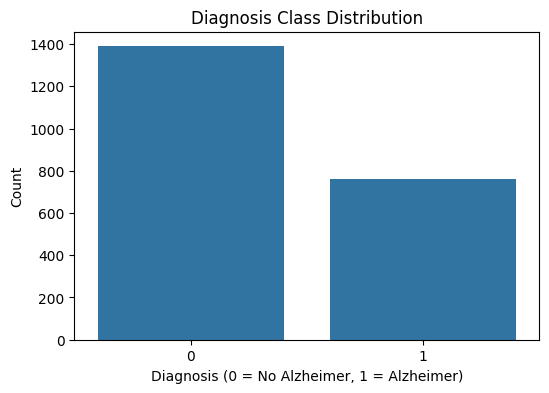

In [4]:
#Target distribution
# Count values
print(data["Diagnosis"].value_counts())

# Percentage distribution
print("\nPercentage Distribution:")
print(data["Diagnosis"].value_counts(normalize=True) * 100)

# Plot distribution
plt.figure(figsize=(6,4))
sns.countplot(x="Diagnosis", data=data)
plt.title("Diagnosis Class Distribution")
plt.xlabel("Diagnosis (0 = No Alzheimer, 1 = Alzheimer)")
plt.ylabel("Count")
plt.show()

['PatientID', 'Age', 'Gender', 'Ethnicity', 'EducationLevel', 'BMI', 'Smoking', 'AlcoholConsumption', 'PhysicalActivity', 'DietQuality', 'SleepQuality', 'FamilyHistoryAlzheimers', 'CardiovascularDisease', 'Diabetes', 'Depression', 'HeadInjury', 'Hypertension', 'SystolicBP', 'DiastolicBP', 'CholesterolTotal', 'CholesterolLDL', 'CholesterolHDL', 'CholesterolTriglycerides', 'MMSE', 'FunctionalAssessment', 'MemoryComplaints', 'BehavioralProblems', 'ADL', 'Confusion', 'Disorientation', 'PersonalityChanges', 'DifficultyCompletingTasks', 'Forgetfulness', 'Diagnosis', 'DoctorInCharge']
X shape: (2149, 32)
y shape: (2149,)
Class distribution:
 Diagnosis
0    1389
1     760
Name: count, dtype: int64

Features: ['Age', 'Gender', 'Ethnicity', 'EducationLevel', 'BMI', 'Smoking', 'AlcoholConsumption', 'PhysicalActivity', 'DietQuality', 'SleepQuality', 'FamilyHistoryAlzheimers', 'CardiovascularDisease', 'Diabetes', 'Depression', 'HeadInjury', 'Hypertension', 'SystolicBP', 'DiastolicBP', 'CholesterolT

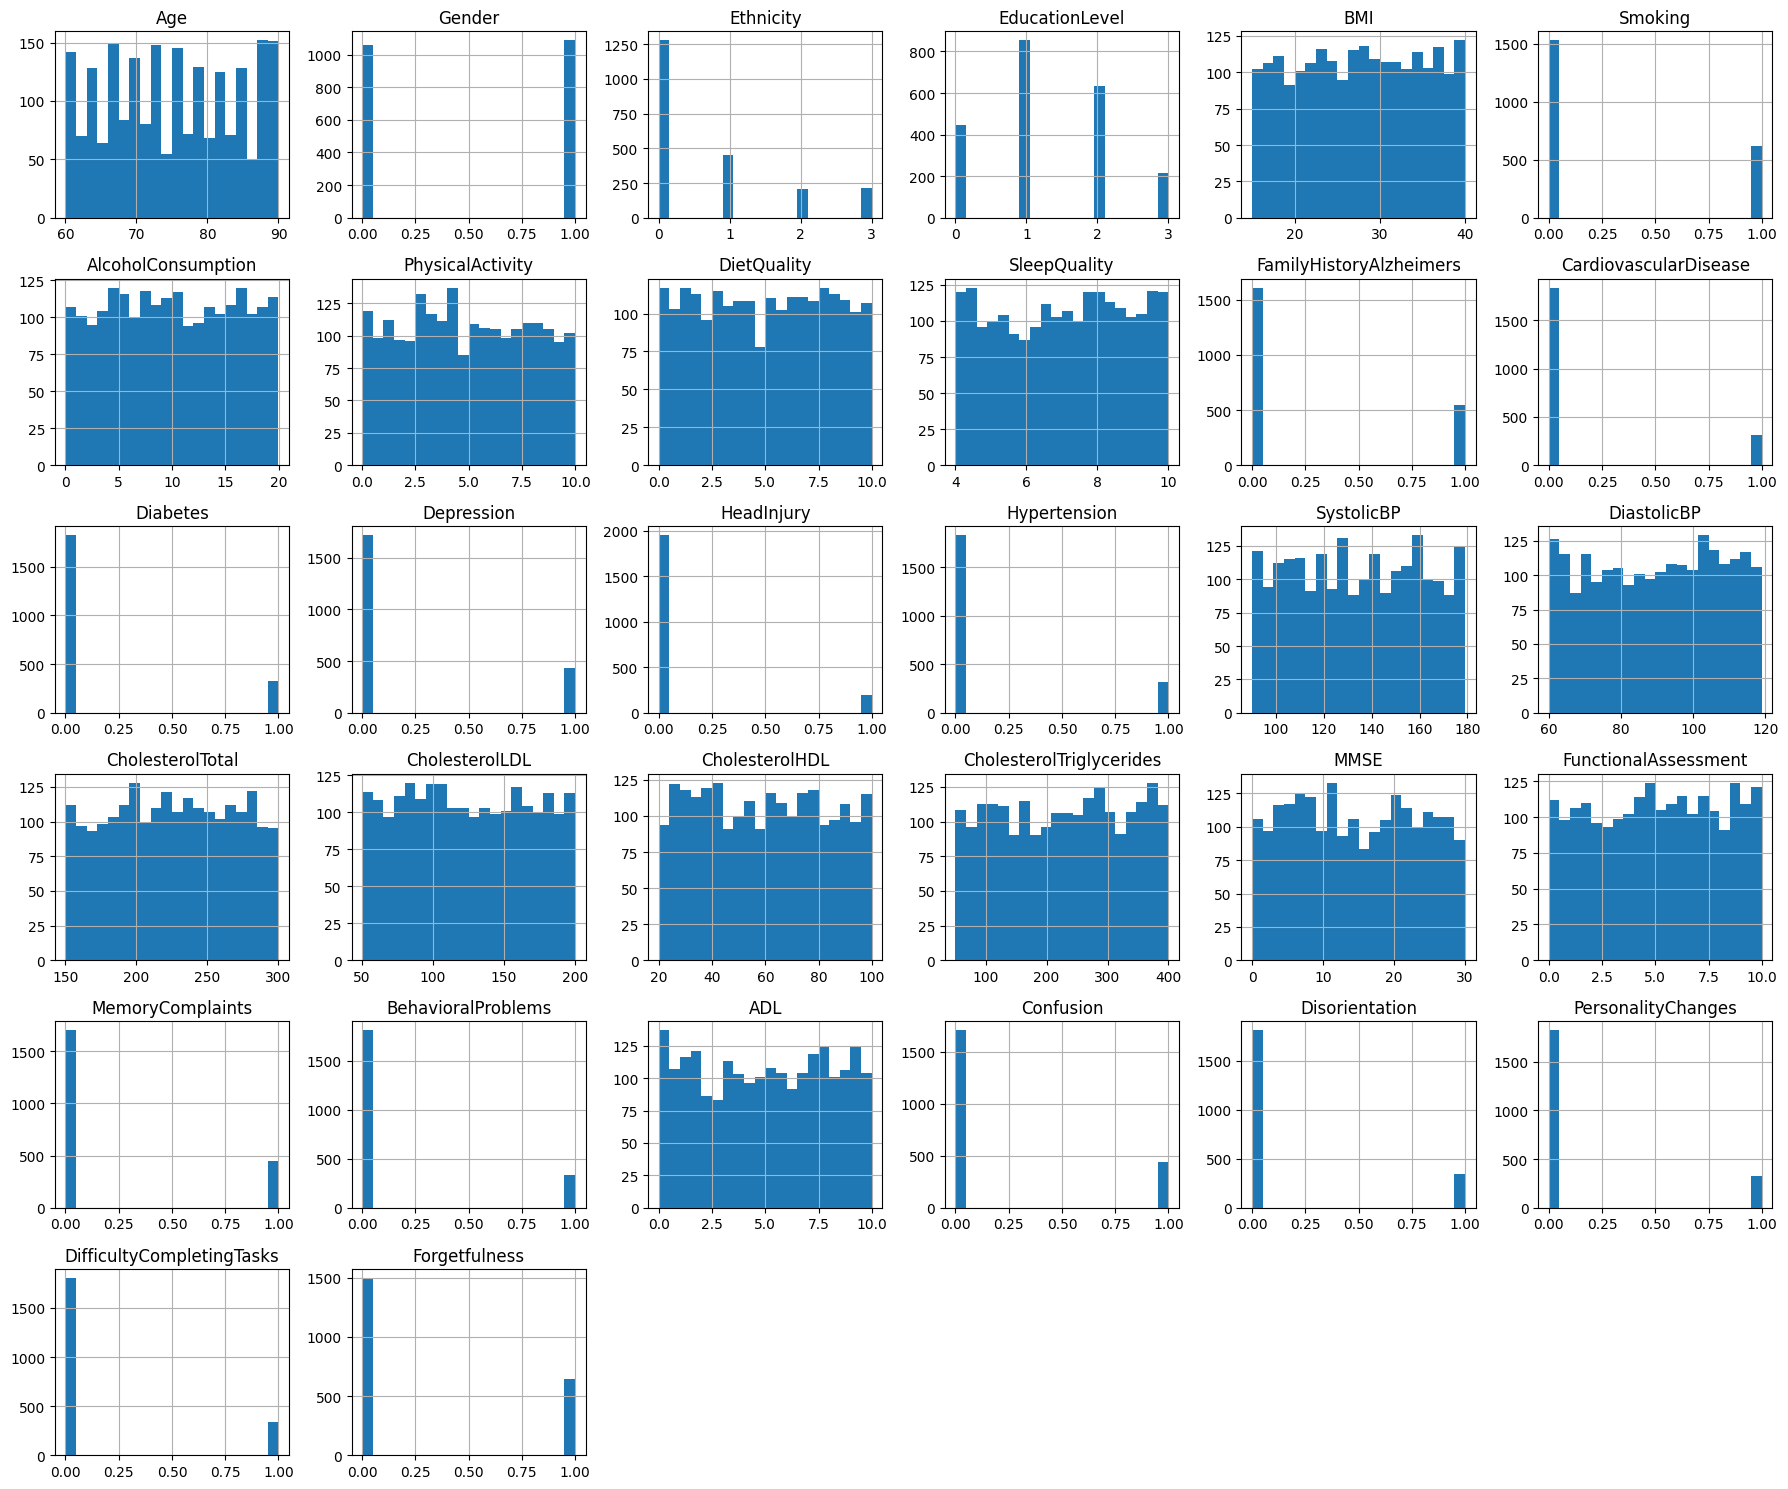

Binary Features: ['Gender', 'Smoking', 'FamilyHistoryAlzheimers', 'CardiovascularDisease', 'Diabetes', 'Depression', 'HeadInjury', 'Hypertension', 'MemoryComplaints', 'BehavioralProblems', 'Confusion', 'Disorientation', 'PersonalityChanges', 'DifficultyCompletingTasks', 'Forgetfulness']


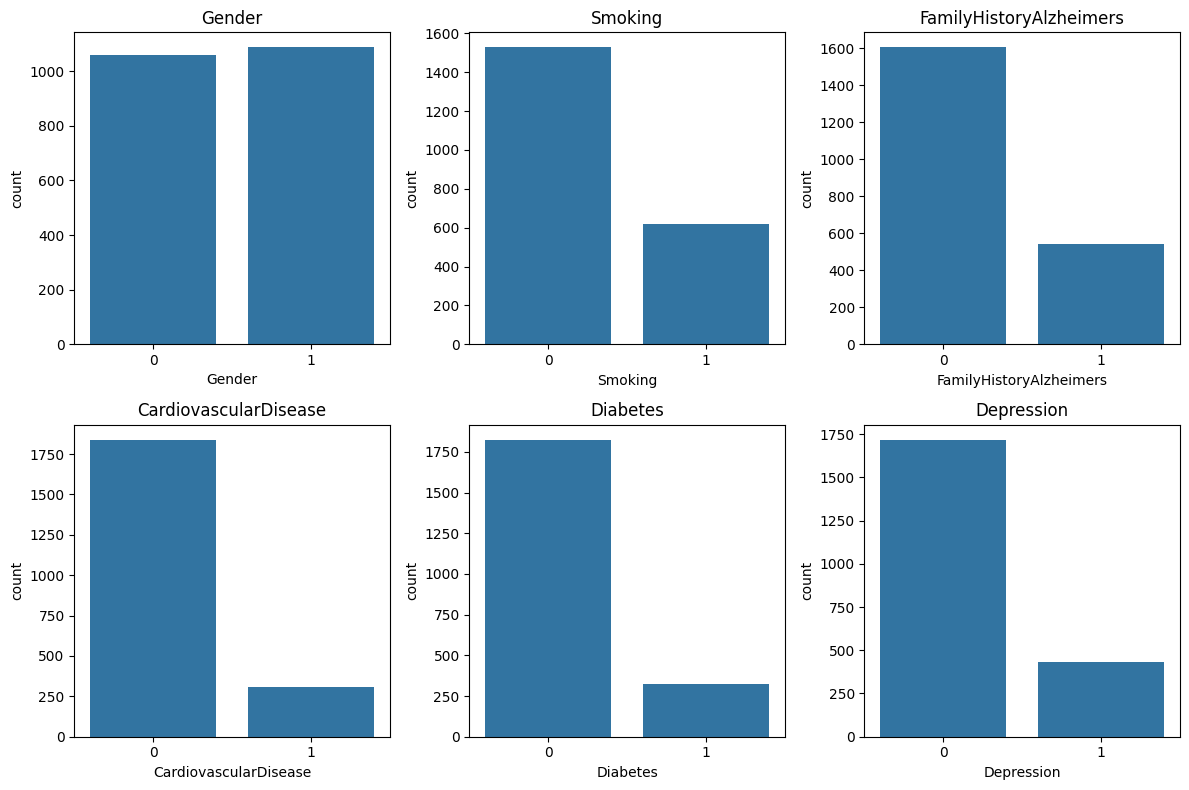

In [5]:
# Define Features (X) and Target (y)

print(data.columns.tolist())
## Define target variable
y = data["Diagnosis"].astype(int)

# Define features — drop Diagnosis, DoctorInCharge (all "XXXConfid"),
# AND PatientID (sequential ID, no clinical meaning = data leakage)
X = data.drop(columns=["Diagnosis", "DoctorInCharge", "PatientID"])

print("X shape:", X.shape)      # should now be (2149, 32) instead of (2149, 33)
print("y shape:", y.shape)
print("Class distribution:\n", y.value_counts())
print("\nFeatures:", X.columns.tolist())

print("Unique target values:", y.unique())

#check data 

# 2. Numerical Feature Distribution

numerical_cols = X.select_dtypes(include=["int64", "float64"]).columns

print("Numerical Features:", numerical_cols)
X[numerical_cols].hist(figsize=(18,15), bins=20)
plt.tight_layout()
plt.show()

binary_cols = [col for col in X.columns if X[col].nunique() == 2]

print("Binary Features:", binary_cols)

plt.figure(figsize=(12,8))

for i, col in enumerate(binary_cols[:6], 1):
    plt.subplot(2,3,i)
    sns.countplot(x=col, data=data)
    plt.title(col)

plt.tight_layout()
plt.show()

Diagnosis                    1.000000
MemoryComplaints             0.306742
BehavioralProblems           0.224350
CholesterolHDL               0.042584
PatientID                    0.041019
Hypertension                 0.035080
CardiovascularDisease        0.031490
BMI                          0.026343
CholesterolTriglycerides     0.022672
DifficultyCompletingTasks    0.009069
DietQuality                  0.008506
CholesterolTotal             0.006394
PhysicalActivity             0.005945
DiastolicBP                  0.005293
Forgetfulness               -0.000354
Smoking                     -0.004865
Age                         -0.005488
Depression                  -0.005893
AlcoholConsumption          -0.007618
Ethnicity                   -0.014782
SystolicBP                  -0.015615
Confusion                   -0.019186
PersonalityChanges          -0.020627
Gender                      -0.020975
HeadInjury                  -0.021411
Disorientation              -0.024648
Diabetes    

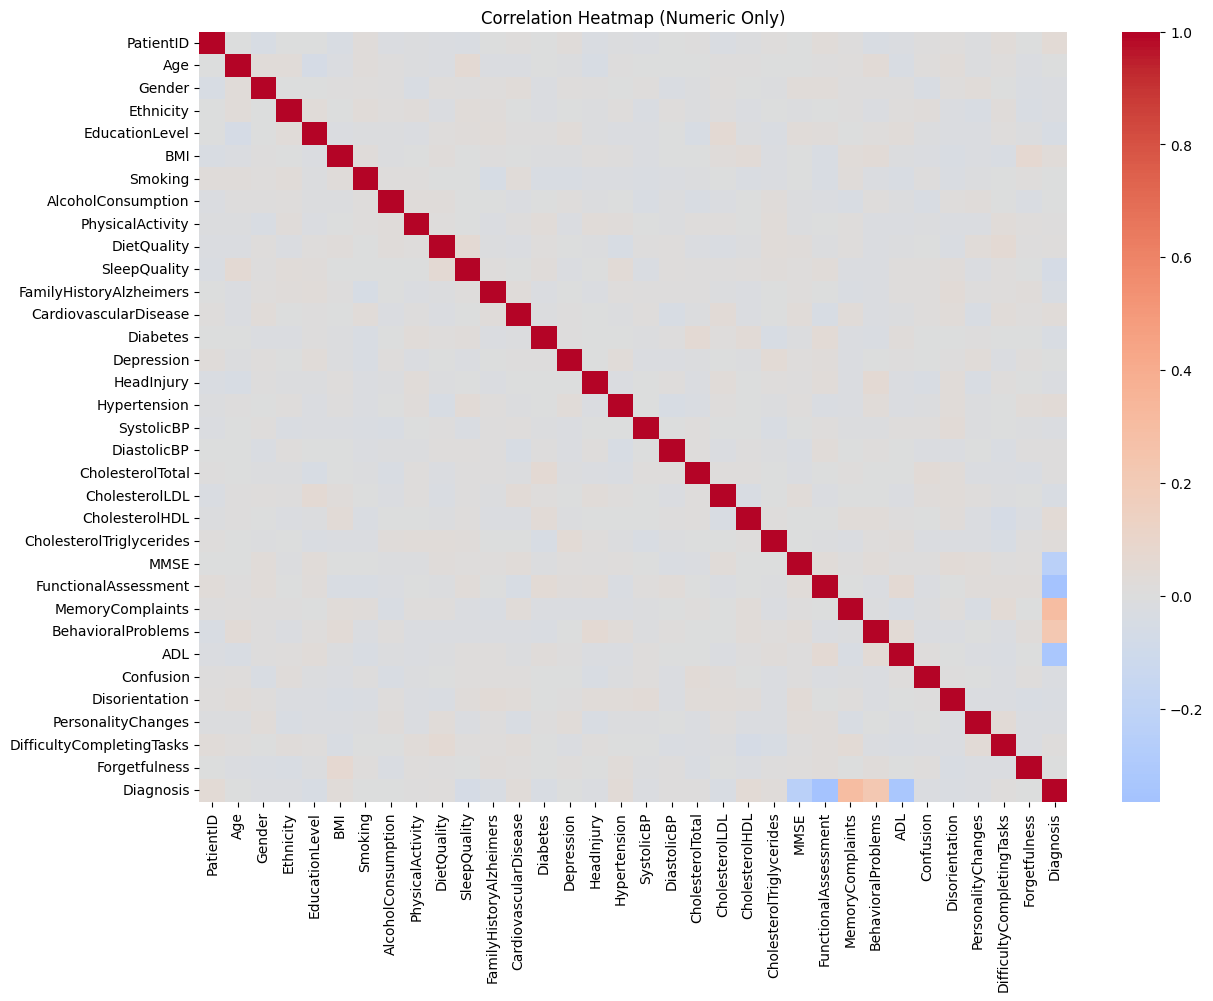

In [6]:
#correlation with target
# Select only numeric columns
numeric_data = data.select_dtypes(include=["int64", "float64"])

# Correlation with target
corr_with_target = numeric_data.corr()["Diagnosis"].sort_values(ascending=False)


print(corr_with_target)

plt.figure(figsize=(14,10))
sns.heatmap(numeric_data.corr(), cmap="coolwarm", center=0)
plt.title("Correlation Heatmap (Numeric Only)")
plt.show()

                      Feature        Chi2       p-value
10           MemoryComplaints  200.623704  1.526605e-45
11         BehavioralProblems  106.879217  4.731447e-25
1                   Ethnicity    6.302089  9.780307e-02
9                Hypertension    2.442487  1.180889e-01
4     FamilyHistoryAlzheimers    2.170309  1.406980e-01
6                    Diabetes    1.953177  1.622450e-01
5       CardiovascularDisease    1.947683  1.628367e-01
2              EducationLevel    4.453147  2.165077e-01
13             Disorientation    1.168140  2.797838e-01
0                      Gender    0.859716  3.538183e-01
8                  HeadInjury    0.836768  3.603227e-01
14         PersonalityChanges    0.797783  3.717571e-01
12                  Confusion    0.694786  4.045414e-01
15  DifficultyCompletingTasks    0.128631  7.198557e-01
7                  Depression    0.047019  8.283335e-01
3                     Smoking    0.030887  8.604932e-01
16              Forgetfulness    0.000000  1.000

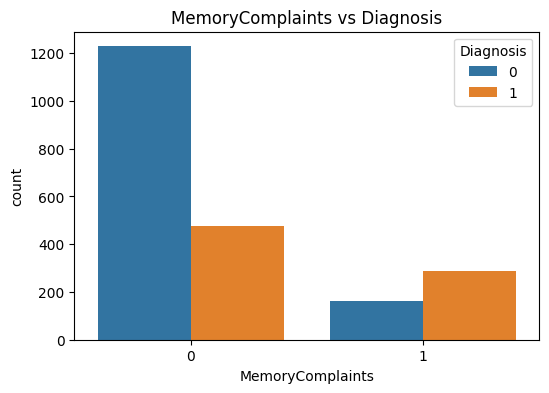

In [7]:
# Chi-Square Test for Categorical Features


from scipy.stats import chi2_contingency

categorical_cols = [
    'Gender', 'Ethnicity', 'EducationLevel', 'Smoking',
    'FamilyHistoryAlzheimers', 'CardiovascularDisease',
    'Diabetes', 'Depression', 'HeadInjury', 'Hypertension',
    'MemoryComplaints', 'BehavioralProblems',
    'Confusion', 'Disorientation', 'PersonalityChanges',
    'DifficultyCompletingTasks', 'Forgetfulness'
]

chi_results = []

for col in categorical_cols:
    contingency_table = pd.crosstab(data[col], data['Diagnosis'])
    chi2, p, dof, expected = chi2_contingency(contingency_table)
    
    chi_results.append((col, chi2, p))

# Convert to DataFrame
chi_df = pd.DataFrame(chi_results, columns=['Feature', 'Chi2', 'p-value'])

# Sort by p-value (most significant first)
chi_df = chi_df.sort_values(by='p-value')

print(chi_df)

plt.figure(figsize=(6,4))
sns.countplot(x="MemoryComplaints", hue="Diagnosis", data=data)
plt.title("MemoryComplaints vs Diagnosis")
plt.show()




                      Feature  MI Score
23       FunctionalAssessment  0.095454
26                        ADL  0.076564
22                       MMSE  0.066278
24           MemoryComplaints  0.052190
25         BehavioralProblems  0.035451
13                 Depression  0.023880
6          AlcoholConsumption  0.017780
20             CholesterolHDL  0.017349
2                   Ethnicity  0.014282
5                     Smoking  0.011560
9                SleepQuality  0.009691
17                DiastolicBP  0.008320
7            PhysicalActivity  0.007947
12                   Diabetes  0.006502
3              EducationLevel  0.002294
11      CardiovascularDisease  0.001392
18           CholesterolTotal  0.000338
27                  Confusion  0.000000
28             Disorientation  0.000000
29         PersonalityChanges  0.000000
30  DifficultyCompletingTasks  0.000000
0                         Age  0.000000
16                 SystolicBP  0.000000
21   CholesterolTriglycerides  0.000000


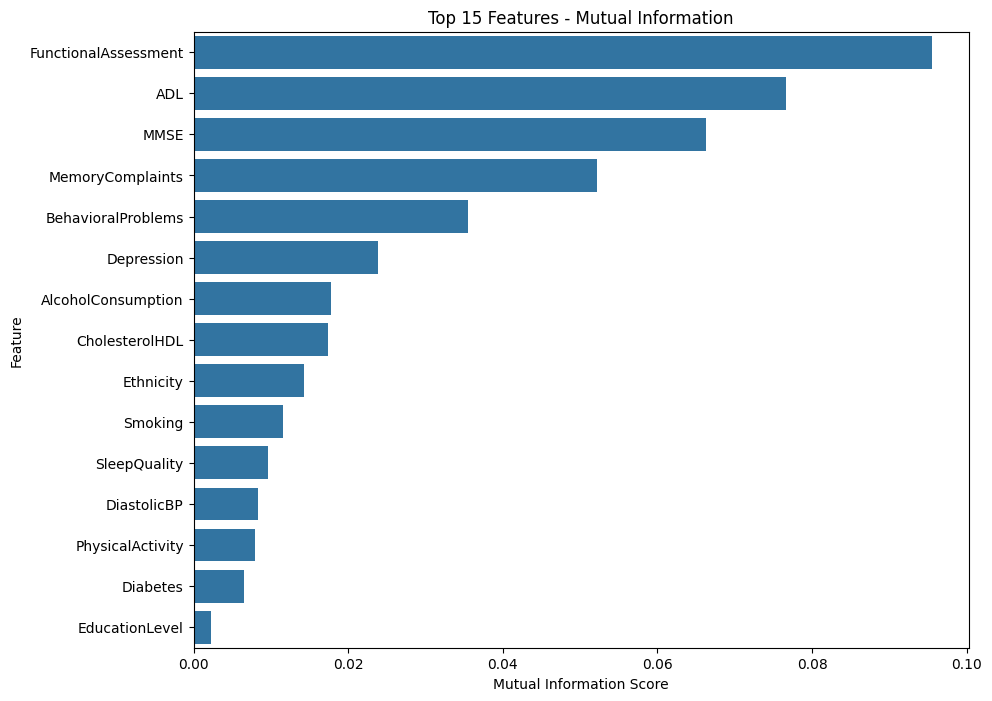

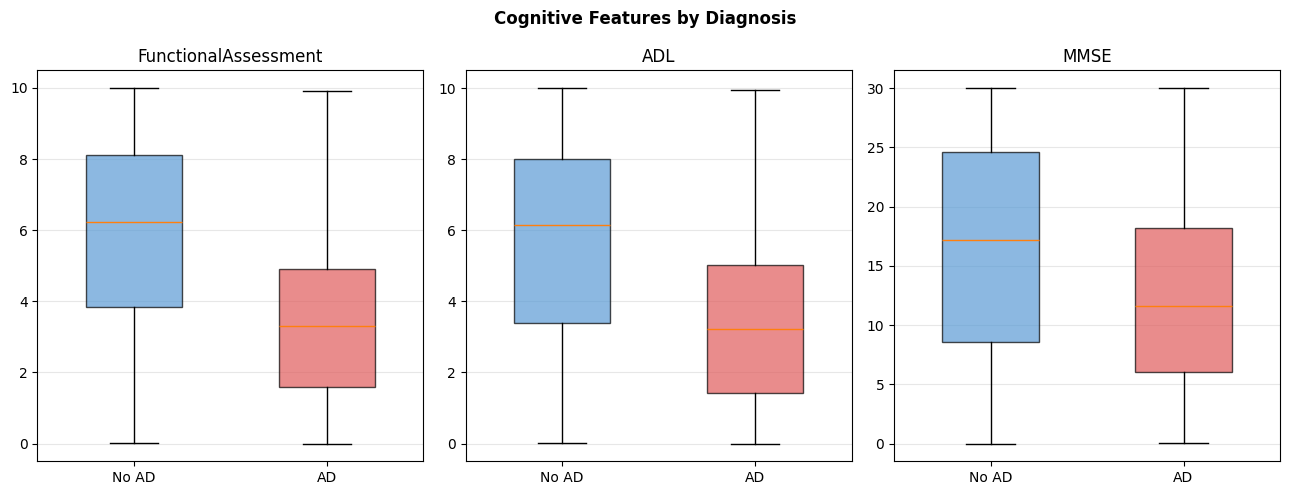

In [8]:
#run Mutual Information
X = data.drop(columns=["Diagnosis", "DoctorInCharge", "PatientID"])
y = data["Diagnosis"].astype(int)

from sklearn.feature_selection import mutual_info_classif

mi_scores = mutual_info_classif(X, y)

mi_df = pd.DataFrame({
    "Feature": X.columns,
    "MI Score": mi_scores
}).sort_values(by="MI Score", ascending=False)

print(mi_df)

plt.figure(figsize=(10,8))

sns.barplot(
    x="MI Score",
    y="Feature",
    data=mi_df.head(15)
)

plt.title("Top 15 Features - Mutual Information")
plt.xlabel("Mutual Information Score")
plt.ylabel("Feature")
plt.show()

fig, axes = plt.subplots(1, 3, figsize=(13, 5))

for ax, feat in zip(axes, ['FunctionalAssessment', 'ADL', 'MMSE']):
    data = [X[feat][y==0], X[feat][y==1]]
    bp = ax.boxplot(data, patch_artist=True, widths=0.5)
    for patch, color in zip(bp['boxes'], ['#5B9BD5','#E05C5C']):
        patch.set_facecolor(color)
        patch.set_alpha(0.7)
    ax.set_xticklabels(['No AD', 'AD'])
    ax.set_title(feat)
    ax.grid(True, alpha=0.3, axis='y')

plt.suptitle('Cognitive Features by Diagnosis', fontweight='bold')
plt.tight_layout()
plt.show()


                      Feature  Coefficient
23       FunctionalAssessment    -1.281453
26                        ADL    -1.228264
24           MemoryComplaints     1.042513
22                       MMSE    -0.911615
25         BehavioralProblems     0.899950
19             CholesterolLDL    -0.125779
20             CholesterolHDL     0.108061
9                SleepQuality    -0.096909
5                     Smoking    -0.095608
14                 HeadInjury    -0.093224
0                         Age    -0.091350
3              EducationLevel    -0.079040
21   CholesterolTriglycerides     0.074490
15               Hypertension     0.070219
27                  Confusion    -0.061393
11      CardiovascularDisease     0.058572
6          AlcoholConsumption    -0.049467
10    FamilyHistoryAlzheimers    -0.047632
28             Disorientation    -0.044182
2                   Ethnicity    -0.036897
30  DifficultyCompletingTasks     0.036018
17                DiastolicBP     0.032241
4          

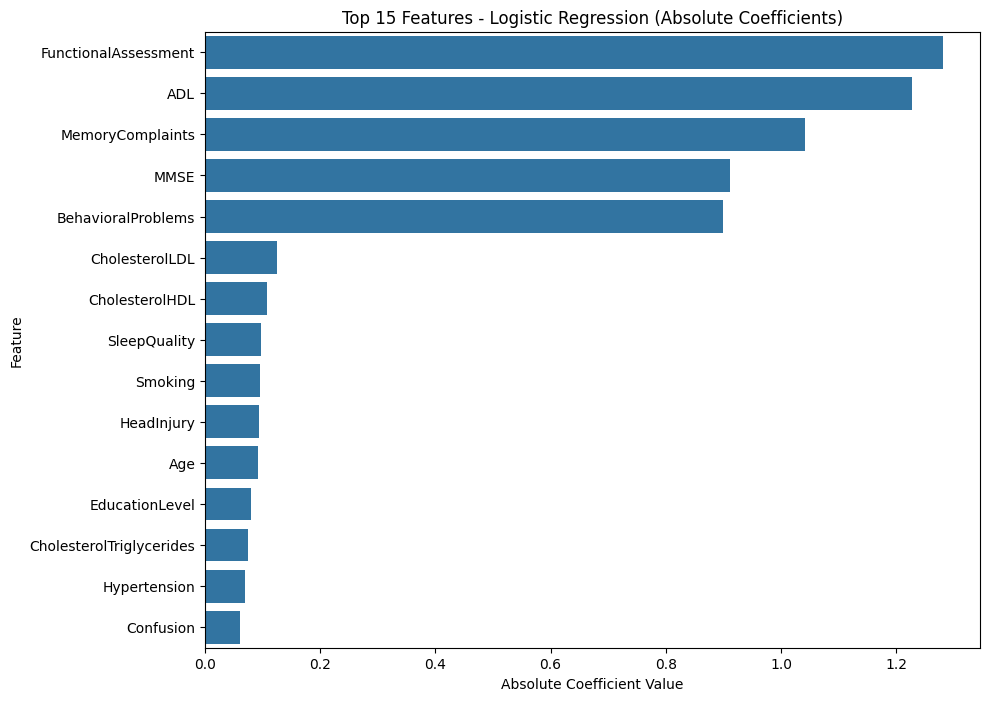

In [9]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

model = LogisticRegression(max_iter=5000)
model.fit(X_scaled, y)

coef_df = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_[0]
}).sort_values(by="Coefficient", key=abs, ascending=False)

print(coef_df)

# Add absolute coefficient column
coef_df["Abs_Coefficient"] = coef_df["Coefficient"].abs()

coef_sorted = coef_df.sort_values(
    by="Abs_Coefficient", ascending=False
).head(15)

plt.figure(figsize=(10,8))

sns.barplot(
    x="Abs_Coefficient",
    y="Feature",
    data=coef_sorted
)

plt.title("Top 15 Features - Logistic Regression (Absolute Coefficients)")
plt.xlabel("Absolute Coefficient Value")
plt.ylabel("Feature")
plt.show()


                      Feature  Importance
23       FunctionalAssessment    0.186329
26                        ADL    0.161961
22                       MMSE    0.130136
24           MemoryComplaints    0.083670
25         BehavioralProblems    0.049218
19             CholesterolLDL    0.030777
8                 DietQuality    0.030307
21   CholesterolTriglycerides    0.029223
6          AlcoholConsumption    0.029117
4                         BMI    0.028366
18           CholesterolTotal    0.028358
20             CholesterolHDL    0.028295
7            PhysicalActivity    0.028094
9                SleepQuality    0.027388
16                 SystolicBP    0.024561
17                DiastolicBP    0.022586
0                         Age    0.021369
3              EducationLevel    0.009381
2                   Ethnicity    0.007772
1                      Gender    0.003923
15               Hypertension    0.003919
5                     Smoking    0.003884
11      CardiovascularDisease    0

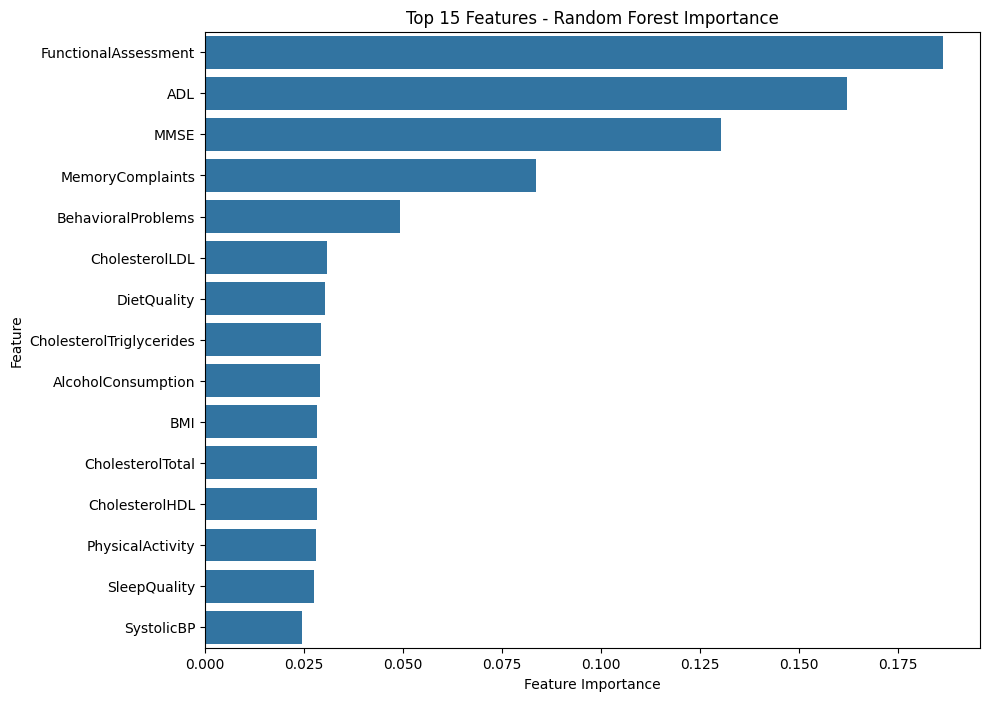

In [10]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(random_state=42)
rf.fit(X, y)

importance_df = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf.feature_importances_
}).sort_values(by="Importance", ascending=False)

print(importance_df)

plt.figure(figsize=(10,8))

sns.barplot(
    x="Importance",
    y="Feature",
    data=importance_df.head(15)
)

plt.title("Top 15 Features - Random Forest Importance")
plt.xlabel("Feature Importance")
plt.ylabel("Feature")
plt.show()


In [11]:
#Comparte Top features from all methods
top_mi = set(mi_df.head(10)["Feature"])
top_rf = set(importance_df.head(10)["Feature"])
top_lr = set(coef_sorted["Feature"])

print("Common Important Features:")
print(top_mi & top_rf & top_lr)


Common Important Features:
{'MMSE', 'BehavioralProblems', 'FunctionalAssessment', 'ADL', 'MemoryComplaints'}


## WORK IN PROGRESS


In [12]:
#Preprocessing Pipeline

# Define Feature Groups
numerical_cols = [
    'Age', 'BMI', 'AlcoholConsumption', 'PhysicalActivity',
    'DietQuality', 'SleepQuality', 'SystolicBP', 'DiastolicBP',
    'CholesterolTotal', 'CholesterolLDL', 'CholesterolHDL',
    'CholesterolTriglycerides', 'MMSE', 'FunctionalAssessment', 'ADL'
]

binary_cols = [
    'Gender', 'Smoking', 'FamilyHistoryAlzheimers',
    'CardiovascularDisease', 'Diabetes', 'Depression',
    'HeadInjury', 'Hypertension', 'MemoryComplaints',
    'BehavioralProblems', 'Confusion', 'Disorientation',
    'PersonalityChanges', 'DifficultyCompletingTasks', 'Forgetfulness'
]

categorical_cols = ['Ethnicity']
ordinal_cols    = ['EducationLevel']

# ── The 6 clinical feature sets ──
# Each set represents what data is realistically
# available in a specific healthcare context.

FEATURE_SETS = {

    # SET 1: Everything available (31 features)
    # Context: Research setting / full specialist workup
    # Includes cognitive tests (MMSE), functional scores (ADL),
    # blood work, all symptoms — the complete picture
    "Full (31 features)": X.columns.tolist(),

    # SET 2: Top 10 by SHAP importance (data-driven reduction)
    # Context: Specialist memory clinic with selective testing
    # These will be populated after SHAP runs in Cell 58,
    # but we pre-define the 10 known from EDA for now
    "Top 10 SHAP": [
        'FunctionalAssessment', 'ADL', 'MMSE',
        'MemoryComplaints', 'BehavioralProblems',
        'AlcoholConsumption', 'CholesterolHDL',
        'DiastolicBP', 'PersonalityChanges', 'SleepQuality'
    ],

    # SET 3: Cognitive + functional assessments only
    # Context: Memory clinic — trained clinician with instruments
    # MMSE = Mini-Mental State Exam (requires trained tester)
    # ADL = Activities of Daily Living scale
    # FunctionalAssessment = standardized functional rating
    # These are the 3 strongest predictors but require
    # specialist equipment/training to collect
    "Cognitive Only (3)": [
        'FunctionalAssessment', 'ADL', 'MMSE'
    ],

    # SET 4: Behavioral symptoms only
    # Context: Family carer or GP observation
    # These are all YES/NO observable behaviors —
    # no instruments needed, a carer can report these
    # This tests: "can we screen with zero clinical tools?"
    "Behavioral Symptoms (6)": [
        'MemoryComplaints', 'BehavioralProblems',
        'Confusion', 'Disorientation',
        'PersonalityChanges', 'Forgetfulness'
    ],

    # SET 5: Primary care accessible features
    # Context: GP / family doctor visit
    # Everything a GP routinely records:
    # vitals, blood work, lifestyle, medical history
    # Does NOT include specialist cognitive tests
    "Primary Care (13)": [
        'Age', 'BMI', 'Smoking', 'AlcoholConsumption',
        'PhysicalActivity', 'DietQuality', 'SleepQuality',
        'FamilyHistoryAlzheimers', 'CardiovascularDisease',
        'Diabetes', 'Depression', 'Hypertension', 'HeadInjury'
    ],

    # SET 6: Community minimum (self-reportable)
    # Context: Online screener / community health worker
    # No clinical visit required — all self-reported
    # Tests the absolute minimum viable screening tool
    "Community Minimum (7)": [
        'Age', 'BMI', 'FamilyHistoryAlzheimers',
        'Depression', 'MemoryComplaints',
        'SleepQuality', 'PhysicalActivity'
    ]
}

# Print summary of each set
print("=" * 55)
print("CLINICAL FEATURE SETS")
print("=" * 55)
for name, features in FEATURE_SETS.items():
    print(f"\n{name}")
    print(f"  Features ({len(features)}): {features}")

print("\n✓ Feature sets defined successfully")


CLINICAL FEATURE SETS

Full (31 features)
  Features (32): ['Age', 'Gender', 'Ethnicity', 'EducationLevel', 'BMI', 'Smoking', 'AlcoholConsumption', 'PhysicalActivity', 'DietQuality', 'SleepQuality', 'FamilyHistoryAlzheimers', 'CardiovascularDisease', 'Diabetes', 'Depression', 'HeadInjury', 'Hypertension', 'SystolicBP', 'DiastolicBP', 'CholesterolTotal', 'CholesterolLDL', 'CholesterolHDL', 'CholesterolTriglycerides', 'MMSE', 'FunctionalAssessment', 'MemoryComplaints', 'BehavioralProblems', 'ADL', 'Confusion', 'Disorientation', 'PersonalityChanges', 'DifficultyCompletingTasks', 'Forgetfulness']

Top 10 SHAP
  Features (10): ['FunctionalAssessment', 'ADL', 'MMSE', 'MemoryComplaints', 'BehavioralProblems', 'AlcoholConsumption', 'CholesterolHDL', 'DiastolicBP', 'PersonalityChanges', 'SleepQuality']

Cognitive Only (3)
  Features (3): ['FunctionalAssessment', 'ADL', 'MMSE']

Behavioral Symptoms (6)
  Features (6): ['MemoryComplaints', 'BehavioralProblems', 'Confusion', 'Disorientation', 'Per

In [13]:
# ── Preprocessing function ──
# Returns a fitted ColumnTransformer for any given feature subset.
# We need a separate preprocessor per feature set because each
# set has different column types present.

def build_preprocessor(feature_list):
    """
    Builds a ColumnTransformer for a given feature subset.
    Automatically detects which column types are present
    in the subset and only applies relevant transforms.
    """
    # Find which columns from each type are in this feature list
    num_in_set = [c for c in numerical_cols  if c in feature_list]
    bin_in_set = [c for c in binary_cols     if c in feature_list]
    cat_in_set = [c for c in categorical_cols if c in feature_list]
    ord_in_set = [c for c in ordinal_cols    if c in feature_list]

    transformers = []

    # Only add StandardScaler if numerical cols exist in this set
    if num_in_set:
        transformers.append(('num', StandardScaler(), num_in_set))

    # Only add OneHotEncoder if Ethnicity is in this set
    if cat_in_set:
        transformers.append(('cat', OneHotEncoder(drop='first'), cat_in_set))

    # Binary and ordinal columns: pass through as-is (already numeric 0/1)
    if bin_in_set:
        transformers.append(('bin', 'passthrough', bin_in_set))

    if ord_in_set:
        transformers.append(('ord', 'passthrough', ord_in_set))

    return ColumnTransformer(transformers=transformers)

print("✓ Preprocessor function defined")


✓ Preprocessor function defined


In [14]:
from imblearn.over_sampling import SMOTE

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y          # same as your original — preserves class ratio
)

print("Split complete:")
print(f"  Train: {X_train.shape} | Test: {X_test.shape}")
print(f"  Train class dist: {dict(y_train.value_counts())}")
print(f"  Test class dist:  {dict(y_test.value_counts())}")

# Apply SMOTE to training set only
# random_state=42 for reproducibility
smote = SMOTE(random_state=42)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

print(f"\nAfter SMOTE:")
print(f"  Train shape: {X_train_sm.shape}")
print(f"  Train class dist: {dict(pd.Series(y_train_sm).value_counts())}")
print("  → Classes are now balanced for training")
print("  → Test set unchanged (real-world distribution preserved)")


Split complete:
  Train: (1719, 32) | Test: (430, 32)
  Train class dist: {0: np.int64(1111), 1: np.int64(608)}
  Test class dist:  {0: np.int64(278), 1: np.int64(152)}

After SMOTE:
  Train shape: (2222, 32)
  Train class dist: {0: np.int64(1111), 1: np.int64(1111)}
  → Classes are now balanced for training
  → Test set unchanged (real-world distribution preserved)


In [15]:
from xgboost import XGBClassifier
from sklearn.model_selection import cross_validate, StratifiedKFold
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

# 10-fold stratified CV — stratified ensures each fold
# has the same class ratio as the full dataset
cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

models = {
    'Random Forest': RandomForestClassifier(
        n_estimators=200,
        random_state=42,
        n_jobs=-1          # use all CPU cores
    ),
    'XGBoost': XGBClassifier(
        n_estimators=200,
        random_state=42,
        eval_metric='logloss',
        verbosity=0        # suppress XGBoost output
    )
}

# Store all results here
# Structure: results[feature_set_name][model_name] = metrics dict
results = {}

print("=" * 65)
print("TRAINING MODELS ACROSS ALL FEATURE SETS (10-Fold CV)")
print("=" * 65)

for set_name, feature_list in FEATURE_SETS.items():

    print(f"\n▶ Feature Set: {set_name}")
    results[set_name] = {}

    # Subset the data to only this feature set's columns
    X_subset = X[feature_list]

    # Build preprocessor for this specific feature subset
    # (only scales/encodes columns that exist in this set)
    preprocessor = build_preprocessor(feature_list)

    for model_name, model in models.items():

        # Build full pipeline:
        # Step 1: preprocessor (scale/encode)
        # Step 2: SMOTE (balance classes) — must be INSIDE CV loop
        #         so synthetic samples are only created from
        #         training folds, never seen in validation folds
        # Step 3: model
        pipeline = ImbPipeline(steps=[
            ('preprocessor', preprocessor),
            ('smote', SMOTE(random_state=42)),  # inside pipeline = no leakage
            ('model', model)
        ])

        # Run cross-validation
        # scoring: multiple metrics at once
        cv_results = cross_validate(
            pipeline,
            X_subset, y,
            cv=cv,
            scoring={
                'accuracy':  'accuracy',
                'roc_auc':   'roc_auc',
                'f1':        'f1',
                'recall':    'recall',     # sensitivity — critical for screening
                'precision': 'precision'
            },
            return_train_score=False,
            n_jobs=-1   # parallel folds
        )

        # Store mean ± std for each metric
        results[set_name][model_name] = {
            'accuracy':  (cv_results['test_accuracy'].mean(),
                          cv_results['test_accuracy'].std()),
            'roc_auc':   (cv_results['test_roc_auc'].mean(),
                          cv_results['test_roc_auc'].std()),
            'f1':        (cv_results['test_f1'].mean(),
                          cv_results['test_f1'].std()),
            'recall':    (cv_results['test_recall'].mean(),
                          cv_results['test_recall'].std()),
            'precision': (cv_results['test_precision'].mean(),
                          cv_results['test_precision'].std()),
        }

        m = results[set_name][model_name]
        print(f"   {model_name:15s} | "
              f"AUC: {m['roc_auc'][0]:.3f}±{m['roc_auc'][1]:.3f} | "
              f"F1: {m['f1'][0]:.3f}±{m['f1'][1]:.3f} | "
              f"Recall: {m['recall'][0]:.3f}±{m['recall'][1]:.3f}")

print("\n✓ All feature set models trained")




TRAINING MODELS ACROSS ALL FEATURE SETS (10-Fold CV)

▶ Feature Set: Full (31 features)
   Random Forest   | AUC: 0.950±0.012 | F1: 0.916±0.018 | Recall: 0.892±0.032
   XGBoost         | AUC: 0.953±0.012 | F1: 0.929±0.014 | Recall: 0.917±0.023

▶ Feature Set: Top 10 SHAP
   Random Forest   | AUC: 0.949±0.014 | F1: 0.932±0.015 | Recall: 0.918±0.026
   XGBoost         | AUC: 0.953±0.012 | F1: 0.926±0.017 | Recall: 0.918±0.027

▶ Feature Set: Cognitive Only (3)
   Random Forest   | AUC: 0.847±0.015 | F1: 0.703±0.026 | Recall: 0.683±0.049
   XGBoost         | AUC: 0.830±0.019 | F1: 0.687±0.028 | Recall: 0.695±0.053

▶ Feature Set: Behavioral Symptoms (6)
   Random Forest   | AUC: 0.669±0.026 | F1: 0.559±0.037 | Recall: 0.532±0.043
   XGBoost         | AUC: 0.668±0.026 | F1: 0.565±0.036 | Recall: 0.539±0.047

▶ Feature Set: Primary Care (13)
   Random Forest   | AUC: 0.522±0.037 | F1: 0.254±0.024 | Recall: 0.195±0.021
   XGBoost         | AUC: 0.510±0.029 | F1: 0.327±0.048 | Recall: 0.300±0

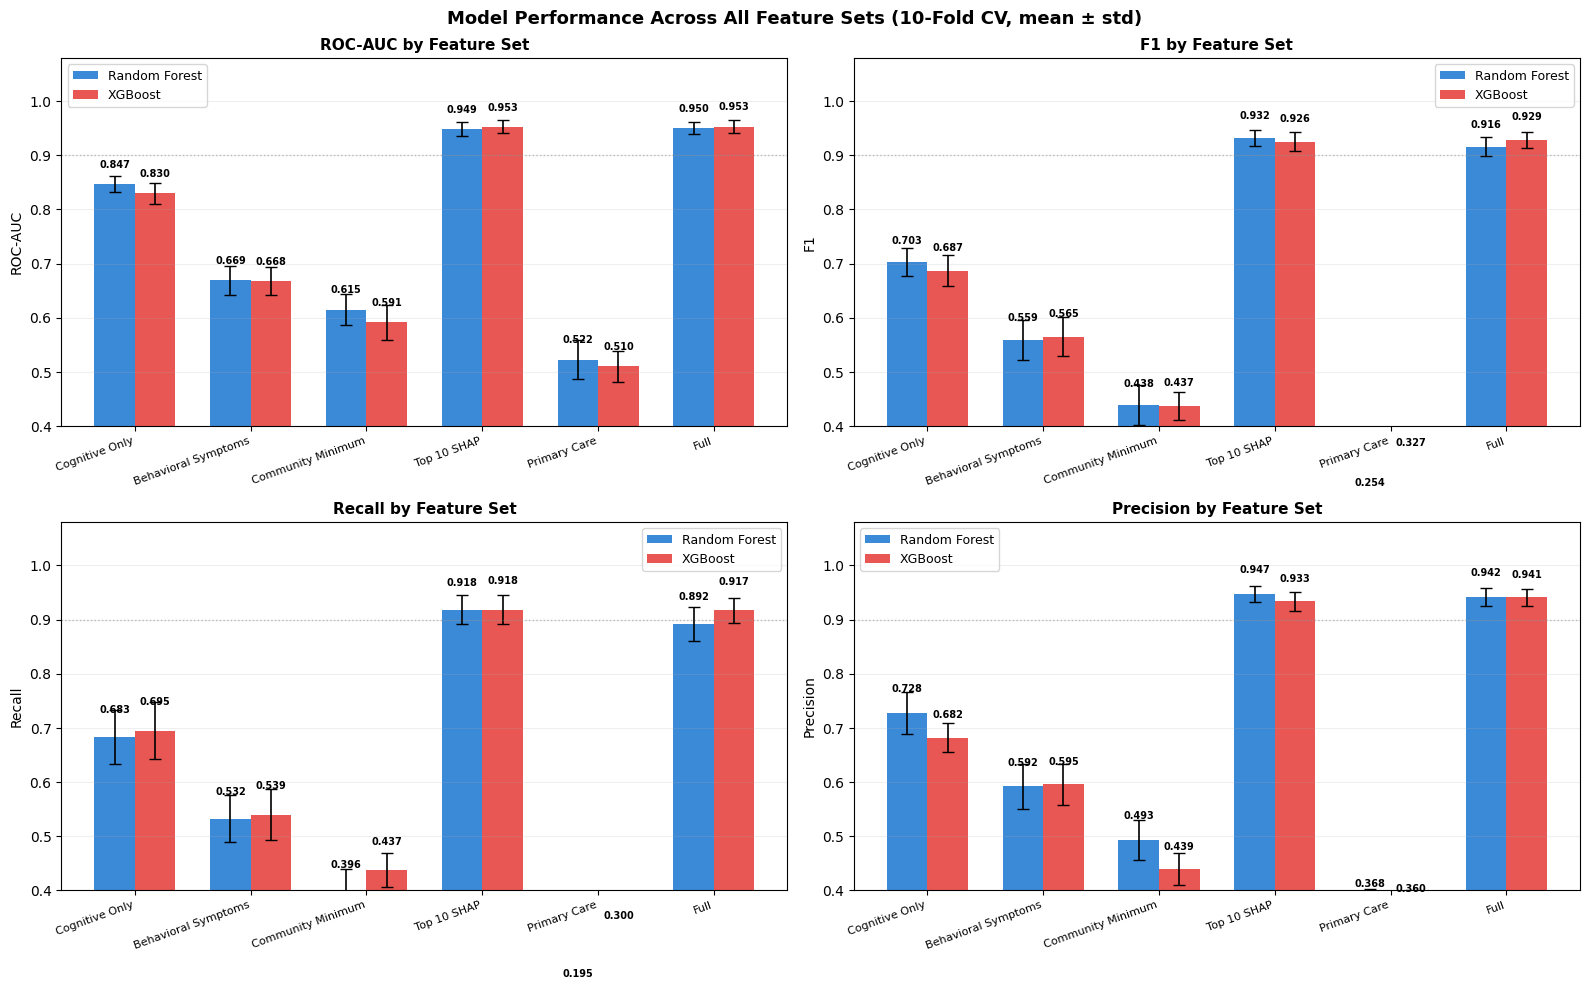

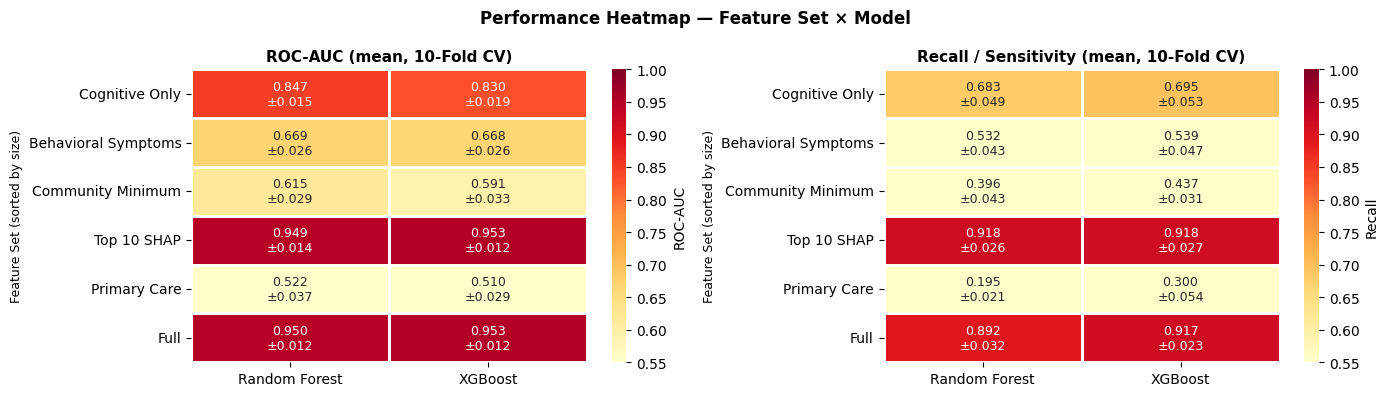

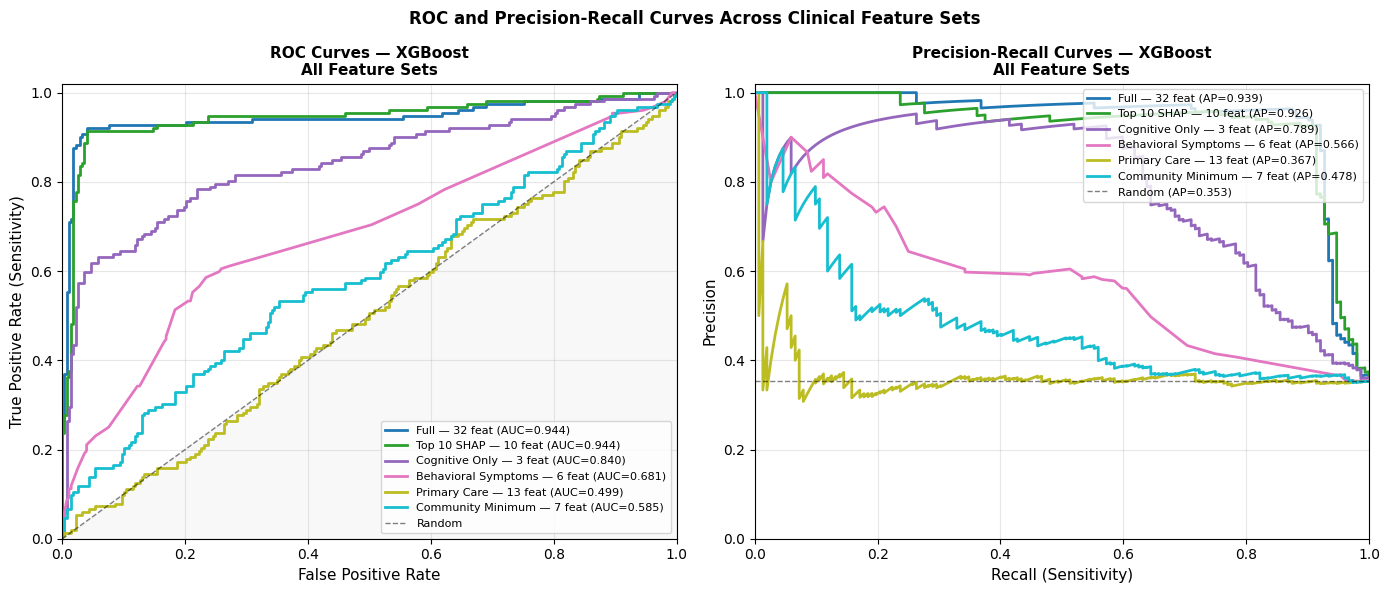

✓ Saved: metrics_bar_chart.png
✓ Saved: metrics_heatmap.png
✓ Saved: roc_pr_curves.png


In [16]:
y = y.astype(int)
y_train = y_train.astype(int)
y_test  = y_test.astype(int)
y_train_sm = y_train_sm.astype(int)

# =============================================================
# CELL 53b — EVALUATION PLOTS FOR ALL FEATURE SETS
# Plots only:
#   1. Grouped bar chart — all metrics side by side
#   2. Heatmap — AUC and Recall across all models/sets
#   3. ROC curves — all feature sets on one chart
#   4. PR curves — all feature sets on one chart
# =============================================================

import matplotlib.gridspec as gridspec
from sklearn.metrics import precision_recall_curve
from sklearn.metrics import average_precision_score

# ── Prepare clean data for plotting ──
plot_data = []
for set_name, feature_list in FEATURE_SETS.items():
    for model_name in models.keys():
        m = results[set_name][model_name]
        plot_data.append({
            'Feature Set':  set_name,
            'Short Name':   set_name.split('(')[0].strip(),  # e.g. "Full"
            'N Features':   len(feature_list),
            'Model':        model_name,
            'Accuracy':     m['accuracy'][0],
            'ROC-AUC':      m['roc_auc'][0],
            'AUC Std':      m['roc_auc'][1],
            'F1':           m['f1'][0],
            'F1 Std':       m['f1'][1],
            'Recall':       m['recall'][0],
            'Recall Std':   m['recall'][1],
            'Precision':    m['precision'][0],
            'Precision Std':m['precision'][1],
        })

plot_df = pd.DataFrame(plot_data)

# Sort by number of features so x-axis reads small → large
plot_df = plot_df.sort_values('N Features')

# Color palette
model_colors = {
    'Random Forest': '#1976D2',
    'XGBoost':       '#E53935'
}

# ── PLOT 1: Grouped bar chart — all 4 metrics ──
metrics_to_plot = ['ROC-AUC', 'F1', 'Recall', 'Precision']
std_cols        = ['AUC Std', 'F1 Std', 'Recall Std', 'Precision Std']

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.flatten()

short_names = plot_df[plot_df['Model'] == 'Random Forest']['Short Name'].tolist()
x = np.arange(len(short_names))
bar_width = 0.35

for ax, metric, std_col in zip(axes, metrics_to_plot, std_cols):

    for i, (model_name, color) in enumerate(model_colors.items()):
        subset = plot_df[plot_df['Model'] == model_name].sort_values('N Features')
        offset = (i - 0.5) * bar_width

        bars = ax.bar(
            x + offset,
            subset[metric],
            width=bar_width,
            color=color,
            alpha=0.85,
            label=model_name,
            yerr=subset[std_col],      # error bar = std across folds
            capsize=4,
            error_kw={'linewidth': 1.2}
        )

        # Value labels on top of each bar
        for bar, val in zip(bars, subset[metric]):
            ax.text(
                bar.get_x() + bar.get_width() / 2,
                bar.get_height() + subset[std_col].mean() + 0.005,
                f'{val:.3f}',
                ha='center', va='bottom',
                fontsize=7, fontweight='bold'
            )

    ax.set_xticks(x)
    ax.set_xticklabels(short_names, rotation=20, ha='right', fontsize=8)
    ax.set_ylabel(metric, fontsize=10)
    ax.set_title(f'{metric} by Feature Set', fontsize=11, fontweight='bold')
    ax.legend(fontsize=9)
    ax.set_ylim(0.4, 1.08)
    ax.axhline(y=0.9, color='gray', linestyle=':', alpha=0.5, linewidth=1)
    ax.grid(True, alpha=0.2, axis='y')

plt.suptitle(
    'Model Performance Across All Feature Sets (10-Fold CV, mean ± std)',
    fontsize=13, fontweight='bold'
)
plt.tight_layout()
plt.savefig('metrics_bar_chart.png', dpi=150, bbox_inches='tight')
plt.show()


# ── PLOT 2: Heatmap — AUC and Recall ──
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

for ax, metric, std_col, title in zip(
    axes,
    ['ROC-AUC', 'Recall'],
    ['AUC Std', 'Recall Std'],
    ['ROC-AUC (mean, 10-Fold CV)', 'Recall / Sensitivity (mean, 10-Fold CV)']
):
    pivot = plot_df.pivot(
        index='Short Name',
        columns='Model',
        values=metric
    )

    # Keep feature-count order
    size_order = (
        plot_df[['Short Name', 'N Features']]
        .drop_duplicates()
        .sort_values('N Features')['Short Name']
        .tolist()
    )
    pivot = pivot.reindex(size_order)

    # Annotation: value + std
    pivot_std = plot_df.pivot(
        index='Short Name', columns='Model', values=std_col
    ).reindex(size_order)

    annot = pivot.copy().astype(str)
    for r in pivot.index:
        for c in pivot.columns:
            annot.loc[r, c] = f"{pivot.loc[r,c]:.3f}\n±{pivot_std.loc[r,c]:.3f}"

    sns.heatmap(
        pivot,
        annot=annot,
        fmt='',
        cmap='YlOrRd',
        vmin=0.55,
        vmax=1.0,
        ax=ax,
        linewidths=0.8,
        cbar_kws={'label': metric},
        annot_kws={'size': 9}
    )
    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.set_xlabel('')
    ax.set_ylabel('Feature Set (sorted by size)', fontsize=9)
    ax.tick_params(axis='x', rotation=0)
    ax.tick_params(axis='y', rotation=0)

plt.suptitle(
    'Performance Heatmap — Feature Set × Model',
    fontsize=12, fontweight='bold'
)
plt.tight_layout()
plt.savefig('metrics_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()


# ── PLOT 3 + 4: ROC and PR curves — all feature sets ──
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

colors = plt.cm.tab10(np.linspace(0, 1, len(FEATURE_SETS)))

# Store for both plots
roc_data = []
pr_data  = []

for (set_name, feature_list), color in zip(FEATURE_SETS.items(), colors):

    pipeline = ImbPipeline(steps=[
        ('preprocessor', build_preprocessor(feature_list)),
        ('smote',  SMOTE(random_state=42)),
        ('model',  XGBClassifier(
            n_estimators=200,
            random_state=42,
            eval_metric='logloss',
            verbosity=0
        ))
    ])
    pipeline.fit(X_train[feature_list], y_train)
    y_prob = pipeline.predict_proba(X_test[feature_list])[:, 1]

    # ROC
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc = roc_auc_score(y_test, y_prob)

    # PR
    prec, rec, _ = precision_recall_curve(y_test, y_prob)
    pr_auc = average_precision_score(y_test, y_prob)

    n = len(feature_list)
    short = set_name.split('(')[0].strip()

    roc_data.append((fpr, tpr, auc,    short, n, color))
    pr_data.append( (rec, prec, pr_auc, short, n, color))

# ROC plot
ax = axes[0]
for fpr, tpr, auc, short, n, color in roc_data:
    ax.plot(fpr, tpr, color=color, linewidth=2,
            label=f'{short} — {n} feat (AUC={auc:.3f})')
ax.plot([0,1],[0,1], 'k--', linewidth=1, alpha=0.5, label='Random')
ax.fill_between([0,1],[0,1], alpha=0.05, color='gray')
ax.set_xlabel('False Positive Rate', fontsize=11)
ax.set_ylabel('True Positive Rate (Sensitivity)', fontsize=11)
ax.set_title('ROC Curves — XGBoost\nAll Feature Sets', fontsize=11, fontweight='bold')
ax.legend(fontsize=8, loc='lower right')
ax.grid(True, alpha=0.3)
ax.set_xlim([0, 1])
ax.set_ylim([0, 1.02])

# PR plot
ax = axes[1]
# Baseline = proportion of positive class in test set
baseline = y_test.mean()
for rec, prec, pr_auc, short, n, color in pr_data:
    ax.plot(rec, prec, color=color, linewidth=2,
            label=f'{short} — {n} feat (AP={pr_auc:.3f})')
ax.axhline(y=baseline, color='k', linestyle='--',
           linewidth=1, alpha=0.5,
           label=f'Random (AP={baseline:.3f})')
ax.set_xlabel('Recall (Sensitivity)', fontsize=11)
ax.set_ylabel('Precision', fontsize=11)
ax.set_title('Precision-Recall Curves — XGBoost\nAll Feature Sets',
             fontsize=11, fontweight='bold')
ax.legend(fontsize=8, loc='upper right')
ax.grid(True, alpha=0.3)
ax.set_xlim([0, 1])
ax.set_ylim([0, 1.02])

plt.suptitle(
    'ROC and Precision-Recall Curves Across Clinical Feature Sets',
    fontsize=12, fontweight='bold'
)
plt.tight_layout()
plt.savefig('roc_pr_curves.png', dpi=150, bbox_inches='tight')
plt.show()

print("✓ Saved: metrics_bar_chart.png")
print("✓ Saved: metrics_heatmap.png")
print("✓ Saved: roc_pr_curves.png")

Accuracy: 0.6767441860465117

Confusion Matrix:
[[237  41]
 [ 98  54]]

Classification Report:
              precision    recall  f1-score   support

           0       0.71      0.85      0.77       278
           1       0.57      0.36      0.44       152

    accuracy                           0.68       430
   macro avg       0.64      0.60      0.61       430
weighted avg       0.66      0.68      0.65       430


ROC-AUC Score: 0.6112978038621735


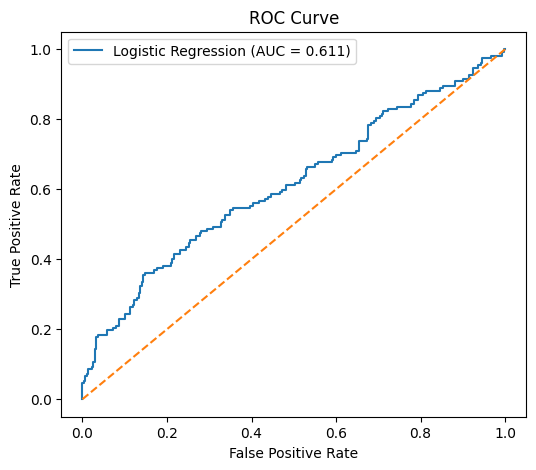

In [17]:
#Logistic Regression Model
class_weight="balanced"

from sklearn.linear_model import LogisticRegression

log_model = Pipeline(steps=[
    ('preprocessing', preprocessor),
    ('model', LogisticRegression(
        max_iter=5000,
        class_weight="balanced",
        random_state=42
    ))
])

# Train
log_model.fit(X_train, y_train)

# Predict class labels
y_pred = log_model.predict(X_test)

# Predict probabilities (for ROC)
y_prob = log_model.predict_proba(X_test)[:, 1]

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score

# Accuracy
acc = accuracy_score(y_test, y_pred)
print("Accuracy:", acc)

# Confusion Matrix
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

# Classification Report
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# ROC-AUC
roc_auc = roc_auc_score(y_test, y_prob)
print("\nROC-AUC Score:", roc_auc)

from sklearn.metrics import roc_curve

fpr, tpr, thresholds = roc_curve(y_test, y_prob)

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f"Logistic Regression (AUC = {roc_auc:.3f})")
plt.plot([0,1], [0,1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()


In [18]:
#Random Forest Model

from sklearn.ensemble import RandomForestClassifier

rf_model = Pipeline(steps=[
    ('preprocessing', preprocessor),
    ('model', RandomForestClassifier(
        n_estimators=200,
        class_weight="balanced",
        random_state=42
    ))
])
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)
y_prob_rf = rf_model.predict_proba(X_test)[:, 1]

# Evaluation

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score

# Accuracy
acc_rf = accuracy_score(y_test, y_pred_rf)
print("Accuracy:", acc_rf)

# Confusion Matrix
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_rf))

# Classification Report
print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf))

# ROC-AUC
roc_auc_rf = roc_auc_score(y_test, y_prob_rf)
print("\nROC-AUC Score:", roc_auc_rf)


Accuracy: 0.6651162790697674

Confusion Matrix:
[[239  39]
 [105  47]]

Classification Report:
              precision    recall  f1-score   support

           0       0.69      0.86      0.77       278
           1       0.55      0.31      0.39       152

    accuracy                           0.67       430
   macro avg       0.62      0.58      0.58       430
weighted avg       0.64      0.67      0.64       430


ROC-AUC Score: 0.6056299697084438


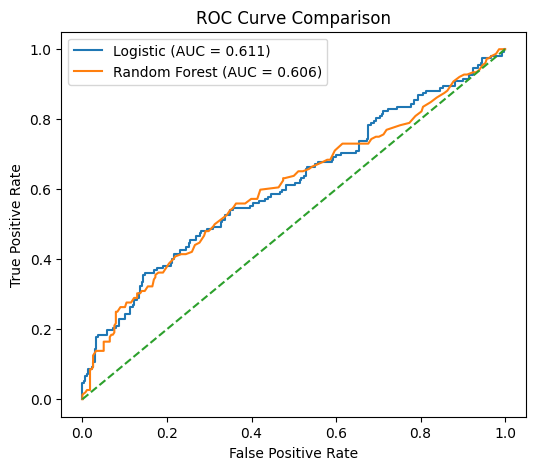

In [19]:
#comparing ROC curves

# Logistic already computed earlier

fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf)

plt.figure(figsize=(6,5))

# Logistic curve
plt.plot(fpr, tpr, label=f"Logistic (AUC = {roc_auc:.3f})")

# Random Forest curve
plt.plot(fpr_rf, tpr_rf, label=f"Random Forest (AUC = {roc_auc_rf:.3f})")

plt.plot([0,1], [0,1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.show()
